In [1]:
!pip install yfinance lightgbm shap -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

btc = yf.download("BTC-USD", start="2020-01-01", progress=False)

if isinstance(btc.columns, pd.MultiIndex):
    btc.columns = btc.columns.get_level_values(0)
btc = btc[["Open", "High", "Low", "Close", "Volume"]].astype(float)

print(f"Veri boyutu: {btc.shape}")
print(f"Tarih aralığı: {btc.index[0].date()} — {btc.index[-1].date()}")
btc.tail(3)

Veri boyutu: (2328, 5)
Tarih aralığı: 2020-01-01 — 2026-05-16


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-05-14,79276.945312,82005.960938,78909.679688,81051.250000,4.373166e+10
2026-05-15,81046.867188,81634.843750,78635.367188,79065.679688,3.818335e+10
2026-05-16,79063.562500,79159.421875,77727.593750,78129.257812,3.122278e+10


In [2]:
def ozellik_uret(df):
    data = df.copy()
    for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
        data[f"lag_{lag}"] = data["Close"].shift(lag)
    for window in [7, 14, 30]:
        data[f"ort_{window}"]  = data["Close"].rolling(window).mean()
        data[f"std_{window}"]  = data["Close"].rolling(window).std()
        data[f"min_{window}"]  = data["Close"].rolling(window).min()
        data[f"max_{window}"]  = data["Close"].rolling(window).max()
    data["getiri"]        = data["Close"].pct_change()
    data["volatilite_7"]  = data["getiri"].rolling(7).std()
    data["volatilite_30"] = data["getiri"].rolling(30).std()
    data["aralik"]        = data["High"].values - data["Low"].values
    data["aralik_pct"]    = data["aralik"].values / data["Close"].values
    data["hacim_degisim"] = data["Volume"].pct_change()
    data["hacim_ort_7"]   = data["Volume"].rolling(7).mean()
    data["ort_fark"]      = data["Close"].rolling(7).mean() - data["Close"].rolling(30).mean()
    fark  = data["Close"].diff()
    kazan = fark.clip(lower=0).rolling(14).mean()
    kayip = (-fark.clip(upper=0)).rolling(14).mean()
    data["RSI"]        = 100 - (100 / (1 + kazan / (kayip + 1e-9)))
    data["gun"]        = data.index.dayofweek
    data["ay"]         = data.index.month
    data["hafta_sonu"] = (data.index.dayofweek >= 5).astype(int)
    data["Hedef"]      = data["Close"].shift(-1)
    data.dropna(inplace=True)
    return data

data = ozellik_uret(btc)
print(f"Özellik sayısı: {data.shape[1]}")
print(f"Gün sayısı: {len(data)}")

Özellik sayısı: 38
Gün sayısı: 2297


In [3]:
ozellik_sutunlar = [c for c in data.columns
                    if c not in ["Open","High","Low","Close","Volume","Hedef"]]

X = data[ozellik_sutunlar]
y = data["Hedef"]

bolme = int(len(data) * 0.80)

X_train = X.iloc[:bolme]
X_test  = X.iloc[bolme:]
y_train = y.iloc[:bolme]
y_test  = y.iloc[bolme:]

esik = 0.01
y_train_esik = np.where(
    y_train.values > X_train["lag_1"].values * (1 + esik), 1,
    np.where(y_train.values < X_train["lag_1"].values * (1 - esik), 0, -1)
)
y_test_esik = np.where(
    y_test.values > X_test["lag_1"].values * (1 + esik), 1,
    np.where(y_test.values < X_test["lag_1"].values * (1 - esik), 0, -1)
)

train_mask = y_train_esik != -1
test_mask  = y_test_esik  != -1

X_train_esik = X_train[train_mask]
y_train_esik = y_train_esik[train_mask]
X_test_esik  = X_test[test_mask]
y_test_esik  = y_test_esik[test_mask]

print(f"Train: {len(X_train_esik)} gün")
print(f"Test : {len(X_test_esik)} gün")
print(f"Test başlangıcı: {X_test.index[0].date()}")

Train: 1354 gün
Test : 310 gün
Test başlangıcı: 2025-02-10


In [4]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from statsmodels.tsa.arima.model import ARIMA

# LightGBM
model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05,
    num_leaves=32, feature_fraction=0.8,
    bagging_fraction=0.8, bagging_freq=5, verbose=-1
)
model.fit(X_train_esik, y_train_esik)
tahmin_lgbm = model.predict(X_test_esik)
acc_lgbm = accuracy_score(y_test_esik, tahmin_lgbm)

# ARIMA
print("ARIMA hesaplanıyor...")
train_close = list(data["Close"].iloc[:bolme])
test_close  = list(data["Close"].iloc[bolme:])
arima_yon   = []

for i in range(min(100, len(test_close)-1)):
    fit  = ARIMA(train_close, order=(5,1,0)).fit()
    yhat = fit.forecast(steps=1)[0]
    arima_yon.append(1 if yhat > train_close[-1] else 0)
    train_close.append(test_close[i])
    if i % 25 == 0:
        print(f"  {i}/100 tamamlandı")

y_test_arima = (np.array(test_close[1:101]) > np.array(test_close[:100])).astype(int)
acc_arima = accuracy_score(y_test_arima, arima_yon)

print(f"\nARIMA    : %{acc_arima*100:.1f}")
print(f"LightGBM : %{acc_lgbm*100:.1f}")

ARIMA hesaplanıyor...
  0/100 tamamlandı
  25/100 tamamlandı
  50/100 tamamlandı
  75/100 tamamlandı

ARIMA    : %48.0
LightGBM : %73.2


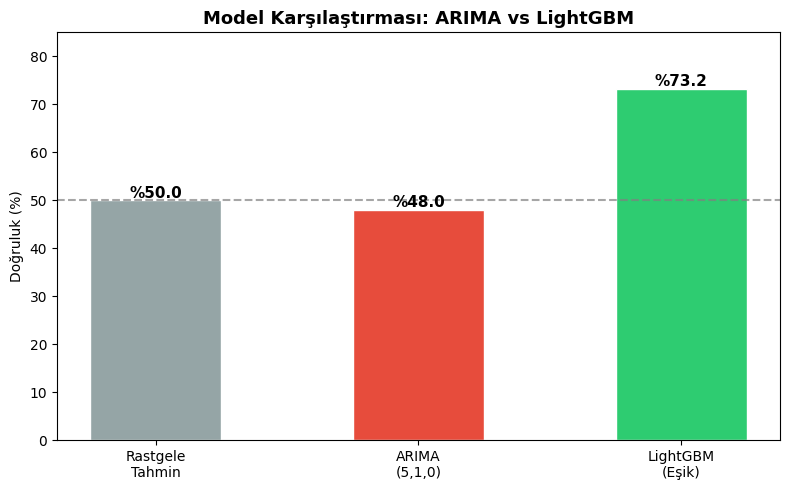

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

modeller = ["Rastgele\nTahmin", "ARIMA\n(5,1,0)", "LightGBM\n(Eşik)"]
dogruluk = [50, acc_arima*100, acc_lgbm*100]
renkler  = ["#95a5a6", "#e74c3c", "#2ecc71"]

bars = ax.bar(modeller, dogruluk, color=renkler, width=0.5, edgecolor="white")
ax.set_ylim(0, 85)
ax.set_ylabel("Doğruluk (%)")
ax.set_title("Model Karşılaştırması: ARIMA vs LightGBM", fontsize=13, fontweight="bold")
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.7, label="Rastgele sınır")

for bar, val in zip(bars, dogruluk):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"%{val:.1f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("model_karsilastirma.png", dpi=150, bbox_inches="tight")
plt.show()

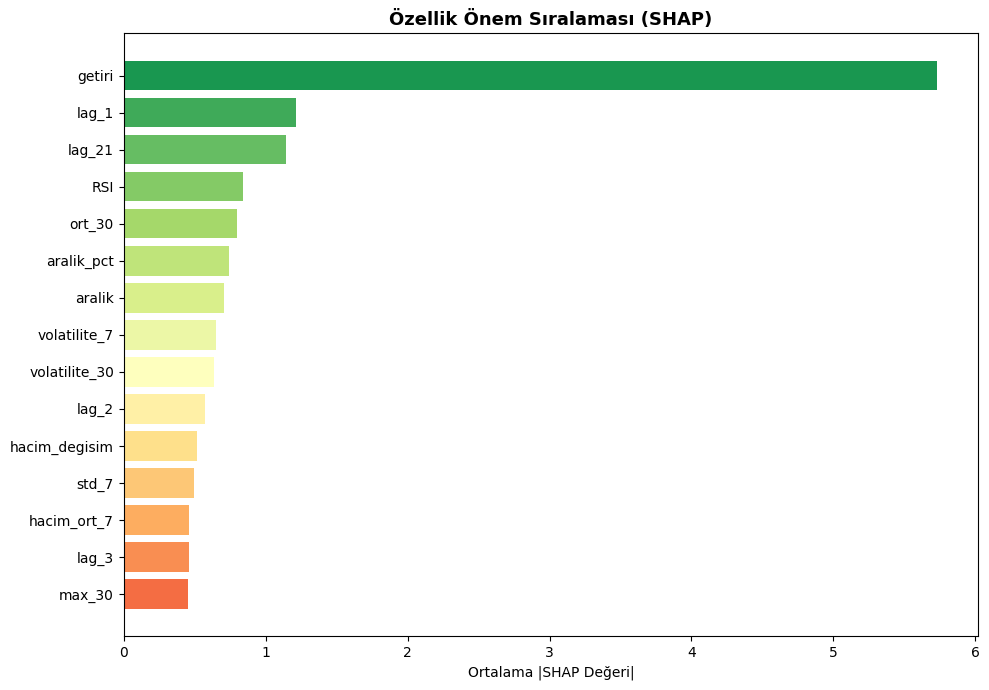

In [6]:
import shap

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_esik)

# Bar plot
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test_esik.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
renkler = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(mean_shap)))
ax.barh(mean_shap.index, mean_shap.values, color=renkler)
ax.set_xlabel("Ortalama |SHAP Değeri|")
ax.set_title("Özellik Önem Sıralaması (SHAP)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
from google.colab import files

files.download("model_karsilastirma.png")
files.download("shap_bar.png")
print("✅ Görseller indirildi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Görseller indirildi
